# RAG pour les opérations retail : Maison Kurt

POC d'assistant IA pour retrouver rapidement une procédure dans une documentation retail. Maison Kurt et sa documentation sont fictives, aucune valeur contractuelle.

**Corpus** (`data/`, 4 guides) : cas particuliers, commandes en ligne, remboursements, retours et échanges.

**Cible** : un conseiller de vente ou un membre du service client qui doit retrouver la procédure applicable à une situation, sans avoir à ouvrir plusieurs documents.

**Jeu de questions** : `questions.json` contient 15 questions avec les mots-clés attendus, utilisées pour évaluer le retrieval et la génération.

**Pipeline** : documents → chunks → embeddings → index FAISS → retrieval → contexte → génération → évaluation.

**Modèles** :
- Embeddings : `intfloat/multilingual-e5-small` (local, CPU)
- Base vectorielle : FAISS
- LLM : `llama3.2` via Ollama (alternative : OpenAI, via `LLM_PROVIDER`)

Le notebook vérifie séparément : le retrieval (hit-rate), la génération (contexte réellement transmis, réponse produite), la fidélité et l'exactitude (LLM-as-a-judge), et le garde-fou sur des questions hors périmètre.

> Limite : le hit-rate est une approximation par mots-clés, pas un Recall@k annoté. Le jeu de questions sert à illustrer la méthode d'évaluation, pas à mesurer une performance de production.

## 1. Installation / Imports

In [1]:
# À exécuter uniquement si nécessaire (le notebook est dans notebook/, requirements.txt à la racine) :
%pip install -r ../requirements.txt
%pip install ipykernel

  Using cached langchain_core-0.3.75-py3-none-any.whl.metadata (5.7 kB)
  Using cached langchain_community-0.3.29-py3-none-any.whl.metadata (2.9 kB)
  Using cached langchain_huggingface-0.3.1-py3-none-any.whl.metadata (996 bytes)
  Using cached langchain_ollama-0.3.7-py3-none-any.whl.metadata (2.1 kB)
  Using cached sentence_transformers-5.1.0-py3-none-any.whl.metadata (16 kB)
  Using cached faiss_cpu-1.12.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached streamlit-1.49.1-py3-none-any.whl.metadata (9.5 kB)
  Using cached langsmith-0.13.0-py3-none-any.whl.metadata (22 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached langchain-1.4.2-py3-none-any.whl.metadata (6.2 kB)
  Using cached sqlalchemy-2.0.54-cp312-cp312-win_amd64.whl.metadata (9.9 


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys
import os

# Configuration du LLM choisi pour ce projet
os.environ["LLM_PROVIDER"] = "ollama"
os.environ["OLLAMA_MODEL"] = "llama3.2"

HERE = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        p for p in (HERE, HERE.parent)
        if (
            (p / "questions.json").exists()
            and (p / "data").is_dir()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Impossible de trouver la racine du projet. "
        "Ouvre VS Code sur le dossier retail-operations-rag."
    )

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ROOT = PROJECT_ROOT
DATA_DIR = ROOT / "data"
QUESTIONS = ROOT / "questions.json"

print("Racine du projet :", ROOT)
print("Dossier data     :", DATA_DIR)
print("questions.json   :", QUESTIONS.exists())
print("requirements.txt :", (ROOT / "requirements.txt").exists())
print("Documents .md    :", len(list(DATA_DIR.glob("*.md"))))

print("\nLLM provider     :", os.environ["LLM_PROVIDER"])
print("LLM model        :", os.environ["OLLAMA_MODEL"])

Racine du projet : C:\Juliette Vanessa\Desktop\Stage\.audit-repos\retail-operations-rag
Dossier data     : C:\Juliette Vanessa\Desktop\Stage\.audit-repos\retail-operations-rag\data
questions.json   : True
requirements.txt : True
Documents .md    : 4

LLM provider     : ollama
LLM model        : llama3.2


## 2. Chargement du corpus / documents


In [3]:
from retail_rag.pipeline import load_markdown_documents

documents = load_markdown_documents(DATA_DIR)

print("Nombre de documents :", len(documents))

for doc in documents:
    print("-", doc.metadata["source"])

Nombre de documents : 4
- guide_cas_particuliers.md
- guide_commandes_en_ligne.md
- guide_remboursements.md
- guide_retours_echanges.md


## 3. Pipeline retrieval / génération

On sépare volontairement le retrieval et la génération, définis directement dans les cellules ci-dessous. Ça permet d'évaluer le retriever sans dépendre du LLM, puis d'envoyer explicitement le contexte récupéré au générateur.

## 4. Chunking

In [4]:
from retail_rag.pipeline import split_documents

# Paramètres du chunking
CHUNK_SIZE = 400
CHUNK_OVERLAP = 50

chunks = split_documents(
    documents, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP
)

print(" PARAMÈTRES DU CHUNKING")
print("=" * 60)
print("Nombre de chunks :", len(chunks))
print("Chunk size       :", CHUNK_SIZE, "caractères")
print("Chunk overlap    :", CHUNK_OVERLAP, "caractères")

# Affichage des premiers chunks
for i, chunk in enumerate(chunks[:5], 1):
    print("\n" + "=" * 70)
    print(f"CHUNK {i} : {len(chunk.page_content)} caractères")
    print("=" * 70)
    print(chunk.page_content)
    print("Source :", chunk.metadata["source"])

 PARAMÈTRES DU CHUNKING
Nombre de chunks : 27
Chunk size       : 400 caractères
Chunk overlap    : 50 caractères

CHUNK 1 : 306 caractères
# Maison Kurt — Guide opérationnel des cas particuliers

Version : 1.0  
Document fictif — usage interne

## 1. Produits de beauté et cosmétiques

Un produit cosmétique ou de beauté ouvert ne peut pas être traité comme un retour standard lorsque son ouverture ne permet plus de garantir son état d'origine.
Source : guide_cas_particuliers.md

CHUNK 2 : 276 caractères
Le conseiller doit vérifier l'état du produit et les conditions applicables à la catégorie avant de valider le retour.

Un produit de beauté non ouvert et dans son état d'origine peut être traité selon les conditions standard applicables.

## 2. Bijoux et accessoires précieux
Source : guide_cas_particuliers.md

CHUNK 3 : 347 caractères
## 2. Bijoux et accessoires précieux

Pour les bijoux et accessoires précieux, la preuve d'achat et l'état d'origine doivent être vérifiés avec une attenti

> **Contrôle du découpage.** Le découpage produit 27 chunks traçables et conserve le nom du fichier source dans les métadonnées. Les exemples affichés montrent que les titres et les règles opérationnelles restent lisibles ; la cellule suivante quantifie la régularité de la longueur des chunks sur l'ensemble du corpus.


In [5]:
lengths = [len(chunk.page_content) for chunk in chunks]

print("Nombre total de chunks :", len(chunks))
print("Chunk le plus court    :", min(lengths), "caractères")
print("Chunk le plus long     :", max(lengths), "caractères")
print("Longueur moyenne       :", round(sum(lengths) / len(lengths)), "caractères")

Nombre total de chunks : 27
Chunk le plus court    : 154 caractères
Chunk le plus long     : 400 caractères
Longueur moyenne       : 328 caractères


**Observations.** 27 chunks, entre 154 et 400 caractères, 328 en moyenne, cohérent avec le `chunk_size` de 400 caractères configuré.

## 5. Embeddings

Chaque chunk est transformé en vecteur numérique par un modèle d'embeddings, `intfloat/multilingual-e5-small`. 

Deux textes de sens proche donnent des vecteurs proches, ce qui permet ensuite de chercher par le sens et pas seulement par mots-clés. 

Ce modèle est multilingue, donc adapté à un corpus en français. La cellule charge le modèle et l'applique au premier chunk pour vérifier qu'il fonctionne.

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings

EMBED_MODEL = "intfloat/multilingual-e5-small"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL
)

print(" MODÈLE D'EMBEDDINGS")
print("=" * 60)
print("Modèle chargé :", EMBED_MODEL)

# Test
test_text = chunks[0].page_content
test_vector = embedding_model.embed_query(test_text)

print("Texte encodé :", len(test_text), "caractères")
print("Vecteur généré :", len(test_vector), "dimensions")

C:\Users\Juliette Vanessa\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 MODÈLE D'EMBEDDINGS
Modèle chargé : intfloat/multilingual-e5-small


Texte encodé : 306 caractères
Vecteur généré : 384 dimensions


**Ce que l'on observe.** Le modèle se charge correctement. Le premier chunk (306 caractères) devient un vecteur de **384 dimensions**. Cette dimension est fixe : elle ne dépend pas de la longueur du texte et sera celle de l'index FAISS. 

**Configuration retenue**

| Élément          | Choix                     |
| ---------------- | ------------------------- |
| Chunk size       | **400**                   |
| Chunk overlap    | **50**                    |
| Embedding        | **multilingual-e5-small** |
| Dimensions       | **384**                   |
| Nombre de chunks | **27**                    |

## 6. FAISS

Les 27 chunks sont vectorisés puis stockés dans un index FAISS, qui sert de base de recherche. 
Avec la configuration par défaut de LangChain, l'index est de type `IndexFlatL2` : la recherche compare la question à tous les vecteurs et renvoie les plus proches en distance euclidienne. Elle est exacte, sans approximation, ce qui convient pour un corpus aussi petit. La cellule vérifie que l'index est bien rempli, puis affiche les chunks avec leur fichier source.

In [7]:
from langchain_community.vectorstores import FAISS

store = FAISS.from_documents(
    chunks,
    embedding_model
)

print("INDEX FAISS")
print("=" * 60)
print("Nombre de chunks :", len(chunks))
print("Nombre de vecteurs dans FAISS :", store.index.ntotal)

for i, doc in enumerate(chunks, 1):
    print(f"\n--- CHUNK {i} ---")
    print(f"Source : {doc.metadata.get('source', 'inconnue')}")
    print(doc.page_content[:500])
    print()

INDEX FAISS
Nombre de chunks : 27
Nombre de vecteurs dans FAISS : 27

--- CHUNK 1 ---
Source : guide_cas_particuliers.md
# Maison Kurt — Guide opérationnel des cas particuliers

Version : 1.0  
Document fictif — usage interne

## 1. Produits de beauté et cosmétiques

Un produit cosmétique ou de beauté ouvert ne peut pas être traité comme un retour standard lorsque son ouverture ne permet plus de garantir son état d'origine.


--- CHUNK 2 ---
Source : guide_cas_particuliers.md
Le conseiller doit vérifier l'état du produit et les conditions applicables à la catégorie avant de valider le retour.

Un produit de beauté non ouvert et dans son état d'origine peut être traité selon les conditions standard applicables.

## 2. Bijoux et accessoires précieux


--- CHUNK 3 ---
Source : guide_cas_particuliers.md
## 2. Bijoux et accessoires précieux

Pour les bijoux et accessoires précieux, la preuve d'achat et l'état d'origine doivent être vérifiés avec une attention particulière.

En cas de doute 

**Ce que l'on observe.** L'index contient **27 vecteurs pour 27 chunks** : aucun chunk n'a été perdu à l'indexation. Chaque chunk garde son fichier source en métadonnée (par exemple `guide_cas_particuliers.md`), ce qui permettra de citer les sources dans les réponses. On voit aussi que certains chunks sont coupés au milieu d'une section (le chunk 1 s'arrête juste avant les conditions de la catégorie). Le retrieval devra donc parfois combiner plusieurs chunks pour couvrir une règle complète.

## 7. Retrieval - Recherche des passages pertinents

Le **retriever** cherche les chunks les plus proches de la question dans l'espace vectoriel.

`k=4` signifie que l'on récupère les **4 passages les plus pertinents**.

### Test

Un **hit** (résultat pertinent) signifie ici que les mots-clés attendus pour la question sont présents dans les passages récupérés.

In [8]:
retriever = store.as_retriever(
    search_kwargs={"k": 4}
)

question = "Quel est le délai de retour d'un article ?"

sources = retriever.invoke(question)

print(" RETRIEVAL")
print("=" * 70)
print("Question :", question)
print("Nombre de sources récupérées :", len(sources))

for i, source in enumerate(sources, 1):
    print("\n" + "=" * 70)
    print(f"SOURCE {i}")
    print("=" * 70)
    print(source.page_content)
    print("Source :", source.metadata["source"])

 RETRIEVAL
Question : Quel est le délai de retour d'un article ?
Nombre de sources récupérées : 4

SOURCE 1
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

SOURCE 2
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

SOURCE 3
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard 

**Observations.** Pour cette question, FAISS renvoie 4 passages : le délai des articles soldés (14 jours), l'échange standard (30 jours), le retour standard (30 jours, c'est le passage attendu), et le cas de dépassement de délai / article défectueux. L'information correcte est bien récupérée, mais elle n'arrive pas en première position.

In [9]:
retriever = store.as_retriever(
    search_kwargs={"k": 4}
)

question = "Les articles soldés peuvent-ils être retournés ?"

sources = retriever.invoke(question)

print(" RETRIEVAL")
print("=" * 70)
print("Question :", question)
print("Nombre de sources récupérées :", len(sources))

for i, source in enumerate(sources, 1):
    print("\n" + "=" * 70)
    print(f"SOURCE {i}")
    print("=" * 70)
    print(source.page_content)
    print("Source :", source.metadata["source"])

 RETRIEVAL
Question : Les articles soldés peuvent-ils être retournés ?
Nombre de sources récupérées : 4

SOURCE 1
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

SOURCE 2
## 3. Article personnalisé défectueux

Un article personnalisé ne peut normalement pas être retourné ou échangé.

Toutefois, lorsqu'un défaut est constaté, le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon.

## 4. Client VIP

Le statut VIP ne modifie pas automatiquement les règles de retour.
Source : guide_cas_particuliers.md

SOURCE 3
La preuve d'achat et l'état d'origine du produit restent requis.

## 4. Arti

> **Deuxième observation sur le retrieval.** Le premier résultat contient la règle correcte pour les articles soldés (les retours restent possibles avec un délai de 14 jours), mais les trois autres passages ne sont que partiellement liés à la question. Cela montre pourquoi le retrieval doit être évalué sur un ensemble de questions, et pourquoi augmenter `k` peut ajouter du bruit autant que du rappel.

La cellule suivante charge le jeu d'évaluation versionné avant de définir un critère de hit déterministe fondé sur les mots-clés.


In [10]:
import json

items = json.loads(
    QUESTIONS.read_text(encoding="utf-8")
)

retriever = store.as_retriever(
    search_kwargs={"k": 4}
)

print("Nombre de questions d'évaluation :", len(items))

Nombre de questions d'évaluation : 15


> **Données d'évaluation.** Le jeu de test contient **15 questions**, dont des questions couvertes par la documentation avec des mots-clés attendus et des cas hors périmètre servant à tester le comportement de refus. La fonction suivante ne note le retrieval que lorsqu'un ensemble de mots-clés attendus existe ; elle ne confond pas l'absence de réponse de référence avec un échec.


In [11]:
from retail_rag.pipeline import evaluate_retrieval

def retrieval_results(k):
    return evaluate_retrieval(store, items, k)

### Inspection question par question

Cette cellule permet de voir précisément quelles questions produisent un **hit** et lesquelles échouent.

In [12]:
K = 4

_, _, rows = retrieval_results(k=K)

for row in rows:
    print("Question :", row["question"])
    print("Hit      :", row["hit"])
    print("Sources  :", row["n_sources"])
    print()

Question : Quel est le délai de retour d'un article standard acheté en magasin ?
Hit      : True
Sources  : 4

Question : Quelles sont les conditions pour accepter le retour d'un article standard ?
Hit      : True
Sources  : 4

Question : Quel est le délai de retour pour un article soldé ?
Hit      : True
Sources  : 4

Question : Un article personnalisé peut-il être retourné ?
Hit      : True
Sources  : 4

Question : Que faire si le client n'a pas sa preuve d'achat ?
Hit      : True
Sources  : 4

Question : Comment est remboursé un achat payé par carte bancaire ?
Hit      : True
Sources  : 4

Question : Que se passe-t-il lorsqu'un article échangé est plus cher ?
Hit      : True
Sources  : 4

Question : Quelle information faut-il rechercher en priorité pour une commande en ligne ?
Hit      : True
Sources  : 4

Question : Que doit faire un conseiller face à un colis reçu endommagé ?
Hit      : True
Sources  : 4

Question : Un client VIP bénéficie-t-il automatiquement de règles de retour 

### Évaluation du retrieval - Hit Rate

Le **retrieval hit-rate** mesure la capacité du moteur de recherche à récupérer l'information attendue.

**Hit Rate = hits / questions évaluables**

Cette mesure évalue le **retriever**.

RETRIEVAL HIT RATE
k=1 | hits=10 | questions=12 | hit rate=83.3%
k=2 | hits=12 | questions=12 | hit rate=100.0%
k=3 | hits=12 | questions=12 | hit rate=100.0%
k=4 | hits=12 | questions=12 | hit rate=100.0%
k=5 | hits=12 | questions=12 | hit rate=100.0%


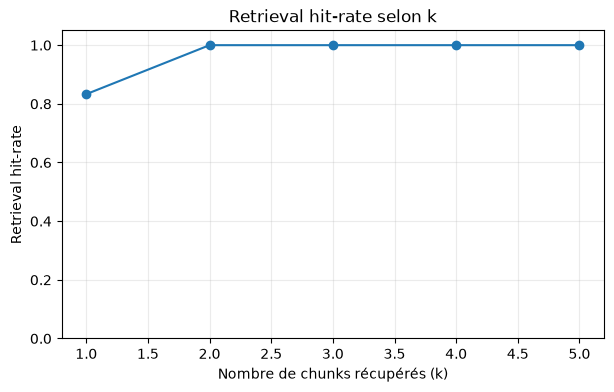

In [13]:
import matplotlib.pyplot as plt

retrieval_summary = []

for k in (1, 2, 3, 4, 5):

    hits, in_scope, rows = retrieval_results(k)

    rate = hits / max(in_scope, 1)

    retrieval_summary.append({
        "k": k,
        "hits": hits,
        "in_scope": in_scope,
        "hit_rate": round(rate, 3)
    })


print("RETRIEVAL HIT RATE")
print("=" * 60)

for result in retrieval_summary:
    print(
        f"k={result['k']} | "
        f"hits={result['hits']} | "
        f"questions={result['in_scope']} | "
        f"hit rate={result['hit_rate']:.1%}"
    )

ks = [r["k"] for r in retrieval_summary]
rates = [r["hit_rate"] for r in retrieval_summary]

plt.figure(figsize=(7, 4))
plt.plot(ks, rates, marker="o")
plt.xlabel("Nombre de chunks récupérés (k)")
plt.ylabel("Retrieval hit-rate")
plt.title("Retrieval hit-rate selon k")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.25)
plt.show()

### Choix de k

Le benchmark du retrieval montre qu'un k=2 permet d'obtenir un Hit Rate de 100 % sur les 12 questions évaluables, contre 83,3 % avec k=1. Au-delà de deux passages, aucune amélioration supplémentaire n'est observée. Le paramètre k=2 a donc été retenu afin de limiter la quantité de contexte transmise au LLM tout en conservant une couverture complète des informations attendues.

In [14]:
K = 2
retriever = store.as_retriever(search_kwargs={"k": K})

print(f"k retenu pour la génération : {K}")

k retenu pour la génération : 2


## 8. Construction de la chaîne de génération

Ici, on ne met volontairement **pas le retriever dans la chaîne de génération**.

Le notebook réalise explicitement :

`question → retriever → sources → context`

puis :

`context + question → prompt → Llama 3.2 → réponse`

Cette séparation évite l'erreur où un dictionnaire `{context, question}` serait envoyé par inadvertance au retriever.

In [15]:
from retail_rag.pipeline import get_llm

print(" Fonction get_llm prête.")
print("LLM :", os.getenv("OLLAMA_MODEL", "llama3.2"))

 Fonction get_llm prête.
LLM : llama3.2


> **Configuration de la génération.** Le client local Llama 3.2 est initialisé à une température de 0 pour des réponses plus reproductibles. La cellule suivante relie le retriever `k=2` retenu à un prompt contraint, qui impose de répondre à partir du contexte et de refuser explicitement lorsque l'information est absente.


In [16]:
from retail_rag.pipeline import build_chain, generate_answer

# K retenu après l'évaluation du retrieval
K = 2

retriever = store.as_retriever(
    search_kwargs={"k": K}
)

PROMPT = (
    "Tu es un assistant d'analyse de documents opérationnels retail.\n\n"

    "Réponds à la question UNIQUEMENT à partir du contexte fourni.\n\n"

    "IMPORTANT :\n"
    "- Lis attentivement toutes les informations pertinentes du contexte.\n"
    "- Si le contexte indique qu'une règle ne s'applique PAS, "
    "réponds clairement que la règle ne s'applique pas.\n"
    "- Les formulations négatives comme « ne modifie pas », "
    "« ne signifie pas automatiquement » ou « ne peut pas » "
    "contiennent des informations importantes et doivent être utilisées "
    "pour répondre à la question.\n"
    "- Ne réponds jamais « Information non trouvée » si le contexte "
    "contient explicitement ou directement la réponse.\n\n"

    "Si aucune information permettant de répondre à la question "
    "n'est présente dans le contexte, réponds EXACTEMENT : "
    "« Information non trouvée dans les documents. »\n\n"

    "Sois concis et factuel.\n"
    "Lorsque tu utilises une information du contexte, cite entre "
    "guillemets l'extrait correspondant.\n\n"

    "Contexte :\n{context}\n\n"
    "Question : {question}\n"
    "Réponse :"
)

generation_chain = build_chain(PROMPT, get_llm(temperature=0.0))

print("Chaîne de génération prête.")
print("K :", K)
print("LLM :", os.getenv("OLLAMA_MODEL", "llama3.2"))

Chaîne de génération prête.
K : 2
LLM : llama3.2


## Test de génération avec traçabilité des sources

On récupère d'abord les sources, puis on transmet **exactement ces sources** au LLM.

In [17]:
question = "Quel est le délai de retour d'un article ?"

# 1. Récupération des passages pertinents
sources = retriever.invoke(question)

# 2. Construction du contexte
context = "\n\n".join(
    source.page_content
    for source in sources
)

# 3. Génération de la réponse
answer = generation_chain.invoke({
    "context": context,
    "question": question
})

print("QUESTION")
print(question)

print("\n" + "=" * 70)
print("SOURCES RÉCUPÉRÉES")
print("=" * 70)

for i, source in enumerate(sources, 1):
    print(f"\n--- SOURCE {i} ---")
    print(source.page_content)
    print("Source :", source.metadata.get("source"))

print("\n" + "=" * 70)
print("RÉPONSE DU LLM")
print("=" * 70)
print(answer)

QUESTION
Quel est le délai de retour d'un article ?

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

RÉPONSE DU LLM
Le délai de retour d'un article est de 14 jours calendaires.


**Observation.** Avec k=2, les deux passages récupérés parlent des articles soldés (14 jours) et de l'échange standard (30 jours). Chez Maison Kurt, retour et échange standard partagent le même délai de 30 jours, donc le bon chiffre est bien dans le contexte, porté par le passage sur l'échange. Le LLM répond pourtant « 14 jours », le chiffre du passage sur les soldés.

## Test avec plusieurs questions

On teste plusieurs questions représentatives des opérations retail pour voir si l'erreur revient.

In [18]:
# La logique réutilisable vit dans src/retail_rag/pipeline.py.
# Le notebook conserve ici une fonction courte liée à ses objets expérimentaux.
def answer_with_current_pipeline(question):
    return generate_answer(question, retriever, generation_chain)

> **Étape de génération réutilisable.** `generate_answer` renvoie à la fois la réponse et les passages récupérés exacts, ce qui préserve la traçabilité de chaque réponse jusqu'à sa source. La cellule suivante l'applique à quatre scénarios retail représentatifs plutôt que d'évaluer un seul exemple favorable.


In [19]:
test_questions = [
    "Quel est le délai de retour pour un article soldé ?",
    "Comment est remboursé un achat payé par carte bancaire ?",
    "Que doit faire un conseiller face à un colis reçu endommagé ?",
    "Une commande Marketplace peut-elle être retournée en magasin ?",
]

for question in test_questions:

    answer, sources = answer_with_current_pipeline(question)

    print("\n" + "=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU LLM")
    print(answer)

    print("\nSOURCES RÉCUPÉRÉES")
    for i, source in enumerate(sources, 1):
        print(f"\n--- SOURCE {i} ---")
        print(source.page_content)
        print("Source :", source.metadata.get("source"))


QUESTION
Quel est le délai de retour pour un article soldé ?

RÉPONSE DU LLM
Selon le contexte, le délai de retour pour un article soldé est de 14 jours calendaires.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md



QUESTION
Comment est remboursé un achat payé par carte bancaire ?

RÉPONSE DU LLM
Selon le contexte, le remboursement d'un achat payé par carte bancaire est réalisé sur la carte utilisée lors de l'achat, sous réserve des possibilités techniques du système de paiement.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Le conseiller doit confirmer que le retour a été enregistré avant d'annoncer que le remboursement est en cours.

## 2. Achat réglé par carte bancaire

Pour un achat réglé par carte bancaire, le remboursement est réalisé sur la carte utilisée lors de l'achat, sous réserve des possibilités techniques du système de paiement.
Source : guide_remboursements.md

--- SOURCE 2 ---
Le client peut voir apparaître le remboursement après plusieurs jours ouvrés selon sa banque.

## 3. Achat réglé par carte cadeau Maison Kurt

Un achat réglé par carte cadeau est remboursé sous la forme d'un crédit sur carte cadeau Maison Kurt, conformément aux règles du système de paiement.
Source : guide_rembourse


QUESTION
Que doit faire un conseiller face à un colis reçu endommagé ?

RÉPONSE DU LLM
Selon le contexte, le conseiller doit enregistrer le signalement et vérifier les informations de livraison, mais il ne doit pas promettre immédiatement un remboursement avant vérification du dossier.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
## 4. Colis reçu endommagé

Lorsqu'un client signale un colis visiblement endommagé à la réception, le conseiller doit enregistrer le signalement et vérifier les informations de livraison.

Il ne doit pas promettre immédiatement un remboursement avant vérification du dossier.

## 5. Article incorrect reçu
Source : guide_commandes_en_ligne.md

--- SOURCE 2 ---
Le produit doit respecter les conditions de retour applicables.

## 3. Click & Collect

Pour une commande Click & Collect, le conseiller doit vérifier le statut de retrait de la commande avant toute opération de retour.

Une commande non retirée et une commande déjà retirée ne suivent pas nécessairement la même


QUESTION
Une commande Marketplace peut-elle être retournée en magasin ?

RÉPONSE DU LLM
Une commande Marketplace peut être retournée en magasin, mais elle doit être vérifiée selon le circuit prévu pour les demandes exceptionnelles, selon le contexte "Toute exception doit être validée selon le circuit prévu pour les demandes exceptionnelles".

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Les conditions particulières applicables au produit doivent être vérifiées avant validation.

## 2. Retour en magasin d'une commande en ligne

Lorsqu'un retour en magasin est autorisé pour une commande en ligne, le conseiller doit retrouver la commande dans le système à partir du numéro de commande ou de la preuve d'achat disponible.
Source : guide_commandes_en_ligne.md

--- SOURCE 2 ---
Toute exception doit être validée selon le circuit prévu pour les demandes exceptionnelles.

Le conseiller ne doit pas promettre une exception au client avant validation.

## 5. Commande Marketplace

Pour un article vendu par 

**Résultats des 4 tests**

| Question | Résultat |
| --- | --- |
| Article soldé | correct |
| Remboursement carte bancaire | correct |
| Colis endommagé | correct |
| Retour Marketplace en magasin | correct (information absente signalée) |

Le pipeline fonctionne comme attendu : question → embeddings → FAISS → 2 chunks → contexte → Llama 3.2 → réponse. Sur le dernier cas, le LLM ne cherche pas à inventer une règle et indique que l'information n'est pas dans les documents.

Sur les 3 premiers cas, le retriever ramène directement le bon passage. Sur le 4ème, il ramène deux passages distincts (Marketplace et retour en magasin) sans lien explicite entre eux, et le LLM comprend correctement qu'aucune règle ne les relie.

k=2 reste retenu pour la suite : le hit-rate est à 100 % et la génération fonctionne correctement sur ces exemples.

### Test du garde-fou

Une application RAG opérationnelle doit savoir refuser de répondre lorsque la documentation ne contient pas l'information.

On teste volontairement des questions hors périmètre.

In [20]:
guardrail_questions = [
    "Quelle est la politique de livraison internationale de Maison Kurt ?",
    "Quels sont les horaires d'ouverture des magasins Maison Kurt ?",
    "Comment contacter le service client par téléphone ?",
    "Quels moyens de paiement sont acceptés en magasin ?",
]

for question in guardrail_questions:

    sources = retriever.invoke(question)

    context = "\n\n".join(
        doc.page_content for doc in sources
    )

    response = generation_chain.invoke({
        "context": context,
        "question": question
    })

    print("=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU LLM")
    print(response)

    print("\nSOURCES RÉCUPÉRÉES")
    for i, source in enumerate(sources, 1):
        print(f"\n--- SOURCE {i} ---")
        print(source.page_content)


QUESTION
Quelle est la politique de livraison internationale de Maison Kurt ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard acheté en magasin peut être retourné dans un délai de 30 jours calendaires à compter de la date d'achat.

--- SOURCE 2 ---
Les règles spécifiques du vendeur peuvent différer des règles applicables aux articles vendus directement par Maison Kurt.

En cas de doute, le dossier doit être orienté vers le support Marketplace.

## 6. Article acheté avec une promotion

Lorsqu'un article a bénéficié d'une promotion, le conseiller doit vérifier les conditions de l'offre avant de déterminer la modalité de remboursement.
QUESTION
Quels sont les horaires d'ouverture des magasins Maison Kurt ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES RÉ

QUESTION
Comment contacter le service client par téléphone ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Les conditions particulières applicables au produit doivent être vérifiées avant validation.

## 2. Retour en magasin d'une commande en ligne

Lorsqu'un retour en magasin est autorisé pour une commande en ligne, le conseiller doit retrouver la commande dans le système à partir du numéro de commande ou de la preuve d'achat disponible.

--- SOURCE 2 ---
## 5. Absence de preuve d'achat

Sans preuve d'achat, le retour ou l'échange n'est pas automatiquement accepté.

Le conseiller doit rechercher une preuve d'achat numérique dans les outils disponibles avant de prendre une décision.

Si aucune preuve ne peut être retrouvée, le dossier doit être transmis au responsable de rayon.

## 6. Dépassement du délai


QUESTION
Quels moyens de paiement sont acceptés en magasin ?

RÉPONSE DU LLM
Selon le guide opérationnel des remboursements, un ticket de caisse, une facture ou une preuve d'achat numérique peut être accepté comme moyen de paiement pour effectuer un remboursement en magasin.

SOURCES RÉCUPÉRÉES

--- SOURCE 1 ---
Pour être accepté, l'article doit être dans son état d'origine, non porté, non utilisé et accompagné de ses étiquettes lorsqu'elles étaient présentes lors de l'achat.

La preuve d'achat doit être présentée. Un ticket de caisse, une facture ou une preuve d'achat numérique peut être accepté.

Un retour conforme donne lieu à un remboursement selon la procédure de remboursement en vigueur.

--- SOURCE 2 ---
# Maison Kurt — Guide opérationnel des remboursements

Version : 1.0  
Document fictif — usage interne

## 1. Remboursement après retour en magasin

Lorsqu'un retour standard est accepté, le remboursement est effectué sur le moyen de paiement utilisé lors de l'achat lorsque cela

**Bilan du garde-fou**

| Question | Résultat |
| --- | --- |
| Livraison internationale | information non trouvée (correct) |
| Horaires des magasins | information non trouvée (correct) |
| Téléphone du service client | information non trouvée (correct) |
| Moyens de paiement acceptés | réponse inventée à partir d'un passage sur les preuves d'achat (incorrect) |

Le garde-fou fonctionne dans 3 cas sur 4. Sur le dernier, la présence d'un contexte récupéré ne suffit pas à empêcher le LLM d'halluciner ou de mal interpréter un passage proche mais hors sujet.

## 9. Évaluation de la chaîne RAG complète

In [21]:


print(" ÉVALUATION DE LA CHAÎNE RAG")
print("=" * 70)

for item in items:
    question = item["question"]

    answer, sources = answer_with_current_pipeline(question)

    print("\n" + "=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU LLM")
    print(answer)

    print("\nSOURCES UTILISÉES")
    for i, source in enumerate(sources, 1):
        print(f"\n--- SOURCE {i} ---")
        print(source.page_content)
        print("Source :", source.metadata.get("source", "inconnue"))

 ÉVALUATION DE LA CHAÎNE RAG



QUESTION
Quel est le délai de retour d'un article standard acheté en magasin ?

RÉPONSE DU LLM
Selon le guide opérationnel des retours et échanges de la maison Kurt, le délai de retour d'un article standard acheté en magasin est de 30 jours calendaires à compter de la date d'achat.

SOURCES UTILISÉES

--- SOURCE 1 ---
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard acheté en magasin peut être retourné dans un délai de 30 jours calendaires à compter de la date d'achat.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md



QUESTION
Quelles sont les conditions pour accepter le retour d'un article standard ?

RÉPONSE DU LLM
Selon le contexte, les conditions pour accepter le retour d'un article standard sont les suivantes :

* L'article doit être dans son état d'origine.
* L'article doit être non porté, non utilisé.
* L'article doit être accompagné de ses étiquettes lorsqu'elles étaient présentes lors de l'achat.
* La preuve d'achat doit être disponible, ce qui peut être un ticket de caisse, une facture ou une preuve d'achat numérique.
* Le retour doit être conforme.

SOURCES UTILISÉES

--- SOURCE 1 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
Pour être accepté, l'article doit être dans son état d'origine, non porté, non utilisé et a


QUESTION
Quel est le délai de retour pour un article soldé ?

RÉPONSE DU LLM
Selon le contexte, le délai de retour pour un article soldé est de 14 jours calendaires.

SOURCES UTILISÉES

--- SOURCE 1 ---
Si le nouvel article est plus cher, le client règle la différence. S'il est moins cher, la différence est remboursée selon la procédure de remboursement.

## 3. Articles soldés

Les articles soldés restent éligibles au retour et à l'échange, sauf mention contraire indiquée au moment de l'achat.

Pour les articles soldés, le délai de retour est de 14 jours calendaires.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
## 2. Échange d'un article standard

Un échange peut être demandé dans un délai de 30 jours calendaires.

L'article doit être dans son état d'origine et la preuve d'achat doit être disponible.

L'échange est effectué sous réserve de disponibilité du nouvel article.
Source : guide_retours_echanges.md



QUESTION
Un article personnalisé peut-il être retourné ?

RÉPONSE DU LLM
Selon le contexte, un article personnalisé ne peut normalement pas être retourné ou échangé, sauf lorsqu'il présente un défaut relevant de la procédure de prise en charge des articles défectueux.

SOURCES UTILISÉES

--- SOURCE 1 ---
## 3. Article personnalisé défectueux

Un article personnalisé ne peut normalement pas être retourné ou échangé.

Toutefois, lorsqu'un défaut est constaté, le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon.

## 4. Client VIP

Le statut VIP ne modifie pas automatiquement les règles de retour.
Source : guide_cas_particuliers.md

--- SOURCE 2 ---
La preuve d'achat et l'état d'origine du produit restent requis.

## 4. Articles personnalisés

Les articles personnalisés à la demande du client ne peuvent pas être retournés ou échangés, sauf lorsqu'ils présentent un défaut relevant de la procédure de prise en charge des articles défectue

...


QUESTION
Un client VIP bénéficie-t-il automatiquement de règles de retour différentes ?

RÉPONSE DU LLM
Non, le statut VIP ne modifie pas automatiquement les règles de retour. Le conseiller doit vérifier le moyen de paiement enregistré avant de confirmer la modalité de remboursement.

SOURCES UTILISÉES

--- SOURCE 1 ---
## 3. Article personnalisé défectueux

Un article personnalisé ne peut normalement pas être retourné ou échangé.

Toutefois, lorsqu'un défaut est constaté, le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon.

## 4. Client VIP

Le statut VIP ne modifie pas automatiquement les règles de retour.
Source : guide_cas_particuliers.md

--- SOURCE 2 ---
Le conseiller doit vérifier le moyen de paiement enregistré avant de confirmer la modalité de remboursement.

## 4. Échange avec différence de prix

Lorsque le nouvel article est plus cher, le client règle la différence au moment de l'échange.

Lorsque le nouvel article est 


QUESTION
Quelle procédure appliquer à un article vendu par un partenaire Marketplace ?

RÉPONSE DU LLM
Selon le contexte, la procédure à appliquer à un article vendu par un partenaire Marketplace est de déposer le dossier dans le support Marketplace en cas de doute.

SOURCES UTILISÉES

--- SOURCE 1 ---
Toute exception doit être validée selon le circuit prévu pour les demandes exceptionnelles.

Le conseiller ne doit pas promettre une exception au client avant validation.

## 5. Commande Marketplace

Pour un article vendu par un partenaire Marketplace, le conseiller doit vérifier le vendeur et les conditions applicables à la commande.
Source : guide_cas_particuliers.md

--- SOURCE 2 ---
Les règles spécifiques du vendeur peuvent différer des règles applicables aux articles vendus directement par Maison Kurt.

En cas de doute, le dossier doit être orienté vers le support Marketplace.

## 6. Article acheté avec une promotion

Lorsqu'un article a bénéficié d'une promotion, le conseiller doi


QUESTION
Une promotion signifie-t-elle automatiquement que l'article ne peut pas être retourné ?

RÉPONSE DU LLM
Une promotion ne signifie pas automatiquement que l'article ne peut pas être retourné, car selon l'article 3 « Article personnalisé défectueux », un article personnalisé ne peut normalement pas être retourné ou échangé, mais lorsqu'un défaut est constaté, le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon.

SOURCES UTILISÉES

--- SOURCE 1 ---
Une promotion ne signifie pas automatiquement que l'article est exclu des retours.

## 7. Demande hors procédure

Lorsqu'aucune procédure du présent guide ne permet de répondre à la situation, le conseiller ne doit pas inventer une règle.

Il doit indiquer que l'information n'est pas disponible dans la documentation consultée et orienter le dossier vers le responsable ou le support compétent.
Source : guide_cas_particuliers.md

--- SOURCE 2 ---
## 3. Article personnalisé défectueux


QUESTION
Quelle est la politique de congés des employés de Maison Kurt ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES UTILISÉES

--- SOURCE 1 ---
Les règles spécifiques du vendeur peuvent différer des règles applicables aux articles vendus directement par Maison Kurt.

En cas de doute, le dossier doit être orienté vers le support Marketplace.

## 6. Article acheté avec une promotion

Lorsqu'un article a bénéficié d'une promotion, le conseiller doit vérifier les conditions de l'offre avant de déterminer la modalité de remboursement.
Source : guide_cas_particuliers.md

--- SOURCE 2 ---
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard acheté en magasin peut être retourné dans un délai de 30 jours calendaires à compter de la date d'achat.
Source : guide_retours_echanges.md

QUESTION
Quel est le salaire d'un conseiller de vente chez Maison Kurt ?

RÉPO


QUESTION
Quels sont les horaires d'ouverture du magasin Maison Kurt ?

RÉPONSE DU LLM
Information non trouvée dans les documents.

SOURCES UTILISÉES

--- SOURCE 1 ---
# Maison Kurt — Guide opérationnel des retours et échanges

Version : 1.0  
Document fictif — usage interne

## 1. Retour d'un article standard

Un article standard acheté en magasin peut être retourné dans un délai de 30 jours calendaires à compter de la date d'achat.
Source : guide_retours_echanges.md

--- SOURCE 2 ---
Le client peut voir apparaître le remboursement après plusieurs jours ouvrés selon sa banque.

## 3. Achat réglé par carte cadeau Maison Kurt

Un achat réglé par carte cadeau est remboursé sous la forme d'un crédit sur carte cadeau Maison Kurt, conformément aux règles du système de paiement.
Source : guide_remboursements.md


**Deux cas à noter avant l'évaluation finale.**

Pour la question sur le statut VIP, le LLM répond correctement sur le fond (« le statut VIP ne modifie pas automatiquement les règles de retour ») mais ajoute une phrase sur le moyen de paiement, tirée d'un second passage récupéré qui ne concerne pas le statut VIP. Le retriever a bien ramené le bon passage en source 1, mais le passage secondaire (du bruit) se retrouve mélangé dans la réponse.

Même constat sur la question des articles en promotion : la réponse est correcte, mais cite un passage sur les articles personnalisés qui n'a rien à voir avec la question.

Ça illustre l'intérêt de séparer retrieval, génération et évaluation : le hit-rate était à 100 % avec k=2, mais ça ne garantit pas que le LLM utilise correctement chacun des passages fournis.

## 10. LLM-as-a-Judge

Un second LLM évalue chaque réponse du RAG selon deux critères, sur une échelle de 0 à 2 :

- **fidélité** : les affirmations de la réponse sont-elles soutenues par le contexte ?
- **exactitude** : la réponse répond-elle correctement à la question ?

Le juge reçoit la question, les mêmes sources que celles transmises au générateur, et la réponse produite par le RAG.

In [22]:
from retail_rag.pipeline import build_chain, context_from_sources, get_llm

judge_llm = get_llm(temperature=0.0)

JUDGE_PROMPT = """
Tu es un évaluateur strict d'un système RAG.

Évalue la réponse uniquement à partir du contexte fourni.

Question :
{question}

Contexte :
{context}

Réponse du RAG :
{answer}

Évalue deux critères :

1. FIDÉLITÉ
0 = la réponse contient des informations inventées ou contredites par le contexte
1 = la réponse contient des informations partiellement soutenues, hors sujet ou insuffisamment justifiées
2 = toutes les affirmations importantes sont soutenues par le contexte

2. EXACTITUDE
0 = la réponse est incorrecte ou contredit le contexte
1 = la réponse est partiellement correcte
2 = la réponse répond correctement à la question selon le contexte

IMPORTANT POUR LES QUESTIONS HORS PÉRIMÈTRE :
Si la question demande une information qui n'est pas présente dans le contexte et que le RAG répond exactement :
"Information non trouvée dans les documents."
alors cette réponse est considérée comme correcte.

Dans ce cas :
FIDÉLITÉ = 2
EXACTITUDE = 2

Une réponse hors périmètre qui invente une information doit en revanche recevoir :
FIDÉLITÉ = 0
EXACTITUDE = 0

Une information vraie mais hors sujet peut diminuer la fidélité, mais ne doit pas automatiquement diminuer l'exactitude si la réponse principale est correcte.

Réponds STRICTEMENT dans ce format :

FIDELITE: 0, 1 ou 2
EXACTITUDE: 0, 1 ou 2
COMMENTAIRE: une phrase courte.
"""

judge_chain = build_chain(JUDGE_PROMPT, judge_llm)

print("LLM-as-a-Judge prêt.")

LLM-as-a-Judge prêt.


> **Configuration du juge.** Un second prompt LLM, à température nulle, note la fidélité et l'exactitude sur une échelle de 0 à 2. Le juge reste un évaluateur imparfait et non une vérité de référence ; la boucle suivante conserve donc chaque question, réponse, contexte et jugement brut pour un contrôle manuel.


In [23]:
judge_results = []

for item in items:

    question = item["question"]

    # 1. Retrieval
    sources = retriever.invoke(question)

    # 2. Construction du contexte
    context = context_from_sources(sources)

    # 3. Génération de la réponse
    answer = generation_chain.invoke({
        "context": context,
        "question": question
    })

    # 4. Évaluation par le juge
    evaluation = judge_chain.invoke({
        "question": question,
        "answer": answer,
        "context": context
    })

    judge_results.append({
        "question": question,
        "answer": answer,
        "evaluation": evaluation
    })

    print("\n" + "=" * 70)
    print("QUESTION")
    print(question)

    print("\nRÉPONSE DU RAG")
    print(answer)

    print("\nJUGEMENT")
    print(evaluation)


QUESTION
Quel est le délai de retour d'un article standard acheté en magasin ?

RÉPONSE DU RAG
Selon le guide opérationnel des retours et échanges de la maison Kurt, le délai de retour d'un article standard acheté en magasin est de 30 jours calendaires à compter de la date d'achat.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exactement conforme au contexte fourni, sans aucune information inventée ou hors sujet.



QUESTION
Quelles sont les conditions pour accepter le retour d'un article standard ?

RÉPONSE DU RAG
Selon le contexte, les conditions pour accepter le retour d'un article standard sont les suivantes :

* L'article doit être dans son état d'origine.
* L'article doit être non porté, non utilisé.
* L'article doit être accompagné de ses étiquettes lorsqu'elles étaient présentes lors de l'achat.
* La preuve d'achat doit être disponible, ce qui peut être un ticket de caisse, une facture ou une preuve d'achat numérique.
* Le retour doit être conforme.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est entièrement conforme au contexte fourni.



QUESTION
Quel est le délai de retour pour un article soldé ?

RÉPONSE DU RAG
Selon le contexte, le délai de retour pour un article soldé est de 14 jours calendaires.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exactement conforme au contexte fourni, qui précise le délai de retour pour un article soldé à 14 jours calendaires.



QUESTION
Un article personnalisé peut-il être retourné ?

RÉPONSE DU RAG
Selon le contexte, un article personnalisé ne peut normalement pas être retourné ou échangé, sauf lorsqu'il présente un défaut relevant de la procédure de prise en charge des articles défectueux.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exactement conforme au contexte, sans aucune information inventée ou hors sujet.



QUESTION
Que faire si le client n'a pas sa preuve d'achat ?

RÉPONSE DU RAG
Si le client n'a pas sa preuve d'achat, le conseiller doit rechercher une preuve d'achat numérique dans les outils disponibles avant de prendre une décision. Si aucune preuve ne peut être retrouvée, le dossier doit être transmis au responsable de rayon.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exactement conforme au contexte, en mentionnant les étapes à suivre en cas d'absence de preuve d'achat.


...


QUESTION
Quelle procédure appliquer à un article vendu par un partenaire Marketplace ?

RÉPONSE DU RAG
Selon le contexte, la procédure à appliquer à un article vendu par un partenaire Marketplace est de déposer le dossier dans le support Marketplace en cas de doute.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exactement conforme au contexte, déposant le dossier dans le support Marketplace en cas de doute, conformément à la procédure spécifique pour les articles vendus par un partenaire Marketplace.



QUESTION
Une promotion signifie-t-elle automatiquement que l'article ne peut pas être retourné ?

RÉPONSE DU RAG
Une promotion ne signifie pas automatiquement que l'article ne peut pas être retourné, car selon l'article 3 « Article personnalisé défectueux », un article personnalisé ne peut normalement pas être retourné ou échangé, mais lorsqu'un défaut est constaté, le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La réponse est exacte et fidèle au contexte, car elle cite explicitement l'article 3 qui précise que l'article personnalisé ne peut normalement pas être retourné ou échangé, mais que le conseiller doit ouvrir un dossier de prise en charge et transmettre le dossier au responsable de rayon lorsqu'un défaut est constaté.



QUESTION
Quelle est la politique de congés des employés de Maison Kurt ?

RÉPONSE DU RAG
Information non trouvée dans les documents.

JUGEMENT
FIDÉLITÉ: 2
EXACTITUDE: 2
COMMENTAIRE: La politique de congés des employés de Maison Kurt n'est pas explicitement mentionnée dans le contexte fourni, mais la réponse "Information non trouvée dans les documents" est correcte car elle indique que l'information n'est pas disponible dans les documents.



QUESTION
Quel est le salaire d'un conseiller de vente chez Maison Kurt ?

RÉPONSE DU RAG
Information non trouvée dans les documents.

JUGEMENT
FIDÉLITÉ: 0
EXACTITUDE: 0
COMMENTAIRE: La réponse "Information non trouvée dans les documents" est une réponse standard qui indique que l'information demandée n'est pas présente dans les documents, mais elle ne fournit pas de justification ni de contexte pour expliquer ce qui se passe avec le salaire d'un conseiller de vente chez Maison Kurt.



QUESTION
Quels sont les horaires d'ouverture du magasin Maison Kurt ?

RÉPONSE DU RAG
Information non trouvée dans les documents.

JUGEMENT
FIDÉLITÉ: 0
EXACTITUDE: 0
COMMENTAIRE: La réponse "Information non trouvée dans les documents" est correcte car elle indique explicitement que l'information demandée n'est pas présente dans les documents.


**Limite du juge.** Sur ce jeu de test, le juge n'est pas toujours cohérent : pour les deux dernières questions hors périmètre, il attribue 0/0 alors que sa propre justification dit explicitement que la réponse « Information non trouvée dans les documents » est correcte. Les scores globaux ci-dessous sont donc à lire comme indicatifs, pas comme une mesure fiable de la qualité du RAG.

### Synthèse des scores du juge

Les scores sont descriptifs pour ce petit jeu de test. Ils ne constituent pas une validation statistique d'un système de production.

In [24]:
from retail_rag.pipeline import parse_judge_scores

score_summary = parse_judge_scores(judge_results)
fidelite_scores = score_summary["fidelity_scores"]
exactitude_scores = score_summary["accuracy_scores"]

print("=" * 70)
print("RÉSULTATS GLOBAUX (LLM-AS-A-JUDGE)")
print("=" * 70)

print("Nombre de questions :", len(judge_results))
print("Scores de fidélité récupérés :", len(fidelite_scores))
print("Scores d'exactitude récupérés :", len(exactitude_scores))

if fidelite_scores:
    print(f"\nFidélité moyenne   : {score_summary['mean_fidelity']:.2f} / 2")

if exactitude_scores:
    print(f"Exactitude moyenne : {score_summary['mean_accuracy']:.2f} / 2")

RÉSULTATS GLOBAUX (LLM-AS-A-JUDGE)
Nombre de questions : 15
Scores de fidélité récupérés : 15
Scores d'exactitude récupérés : 15

Fidélité moyenne   : 1.73 / 2
Exactitude moyenne : 1.73 / 2


## 11. Analyse des résultats

L'évaluation du système RAG a été réalisée à plusieurs niveaux afin de distinguer la qualité de la recherche documentaire de celle de la génération de réponses.

### Résultats du retrieval

Le **Hit Rate** permet d'évaluer la capacité du retriever à récupérer les passages contenant l'information attendue.

Les résultats obtenus sont :

- **k = 1** : 83,3 %
- **k = 2** : 100 %
- **k = 3** : 100 %
- **k = 4** : 100 %
- **k = 5** : 100 %

Le choix de **k = 2** a donc été retenu pour la suite du pipeline. Il permet de récupérer l'ensemble des informations attendues tout en limitant le nombre de passages transmis au LLM.

### Résultats de la génération

Le système a ensuite été testé sur **15 questions**, comprenant des questions directement couvertes par la documentation ainsi que des questions volontairement hors périmètre.

L'évaluation automatique par **LLM-as-a-Judge** donne les résultats suivants :

- **Fidélité moyenne : 1,73 / 2**
- **Exactitude moyenne : 1,73 / 2**

Ces résultats indiquent que les réponses générées sont globalement fidèles au contexte fourni et correspondent correctement aux informations présentes dans la documentation.

Certaines réponses peuvent néanmoins être améliorées, notamment lorsque plusieurs passages sont récupérés et que le modèle reprend des informations secondaires ou provenant d'une autre partie du contexte.

### Test du garde-fou

Les questions hors périmètre permettent également de vérifier que le système ne cherche pas à inventer une réponse lorsque l'information demandée n'est pas présente dans les documents.

Pour ces questions, le système retourne :

> « Information non trouvée dans les documents. »

Le comportement attendu du garde-fou est donc globalement respecté.

### Bilan

Le système présente ainsi un retrieval efficace avec un **Hit Rate de 100 % pour k = 2**, ainsi qu'une qualité de génération globalement satisfaisante selon l'évaluation LLM-as-a-Judge.

Le choix de **k = 2** constitue un compromis entre couverture documentaire et limitation du contexte transmis au modèle de génération.

## 12. Conclusion

### Architecture

```text
Documentation Maison Kurt
        ↓
Découpage en chunks
        ↓
Embeddings Sentence-Transformers
        ↓
Index FAISS
        ↓
Retriever
        ↓
Contexte pertinent
        ↓
Prompt
        ↓
Llama 3.2 / Ollama
        ↓
Réponse avec garde-fou
```

### Ce que démontre ce POC

- pipeline RAG de bout en bout ;
- recherche sémantique sur une documentation opérationnelle ;
- séparation entre **retrieval** et **génération** ;
- mesure du **retrieval hit-rate** ;
- évaluation de la **fidélité** et de l'**exactitude** ;
- gestion des questions hors périmètre ;
- utilisation d'un LLM local avec Ollama.

**Cas d'usage : Maison Kurt, assistant IA pour les opérations retail**

### Décisions et prochaines étapes

1. Conserver `k=2` pour cette version : il atteint 100 % de hit-rate sur les 12 questions évaluables tout en limitant le bruit transmis au LLM.
2. Maintenir la séparation retrieval/génération et afficher les sources pour rendre chaque réponse vérifiable.
3. Ne pas utiliser le score du LLM-as-a-Judge comme validation unique : ses incohérences sur les questions hors périmètre imposent une revue humaine et des métriques déterministes complémentaires.
4. Le notebook se lance depuis le dossier `notebook/` et les dépendances directes sont épinglées dans `requirements.txt`. Prérequis pour le rejouer : Ollama avec `llama3.2:3b` et une connexion internet au premier lancement (téléchargement du modèle d'embeddings).
5. Avant tout déploiement, élargir le corpus de questions, tester les formulations ambiguës, mesurer la latence et définir une procédure d'escalade vers un responsable lorsque les sources sont insuffisantes ou contradictoires.
